In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

SECTOR = "Industry_Sector"
RISK = "Financial_Risk_Label"
RATIOS = ["Debt_Equity_Ratio", "Return_on_Assets", "Working_Capital_Ratio"]

df = pd.read_csv("../data/processed/cleaned_data.csv")
print(df.shape)

(3575, 20)


In [2]:
for col in [SECTOR, RISK]:
    out = pd.DataFrame({
        "count": df[col].value_counts(),
        "proportion": df[col].value_counts(normalize=True).round(3),
    })
    print(f"\n{col}")
    display(out)


Industry_Sector


,count,proportion
Industry_Sector,,
Finance,641,0.179
Manufacturing,601,0.168
Technology,593,0.166
Healthcare,592,0.166
Retail,577,0.161
Energy,571,0.160



Financial_Risk_Label


,count,proportion
Financial_Risk_Label,,
0,3000,0.839
1,575,0.161


In [3]:
mean_ratios = df.groupby(SECTOR)[RATIOS].mean().round(3)
display(mean_ratios)

risk_by_sector = (
    df.groupby(SECTOR)[RISK]
      .agg(risk_rate="mean", at_risk="sum", n="count")
      .sort_values("risk_rate", ascending=False)
      .round(3)
)
display(risk_by_sector)
print("Overall risk rate:", round(df[RISK].mean(), 3))

,Debt_Equity_Ratio,Return_on_Assets,Working_Capital_Ratio
Industry_Sector,,,
Energy,1.087,0.095,5.109
Finance,1.177,0.093,7.362
Healthcare,1.148,0.097,6.396
Manufacturing,1.085,0.096,7.313
Retail,1.044,0.099,6.508
Technology,1.020,0.097,8.207


,risk_rate,at_risk,n
Industry_Sector,,,
Finance,0.192,123,641
Manufacturing,0.165,99,601
Energy,0.161,92,571
Healthcare,0.159,94,592
Technology,0.145,86,593
Retail,0.140,81,577


Overall risk rate: 0.161


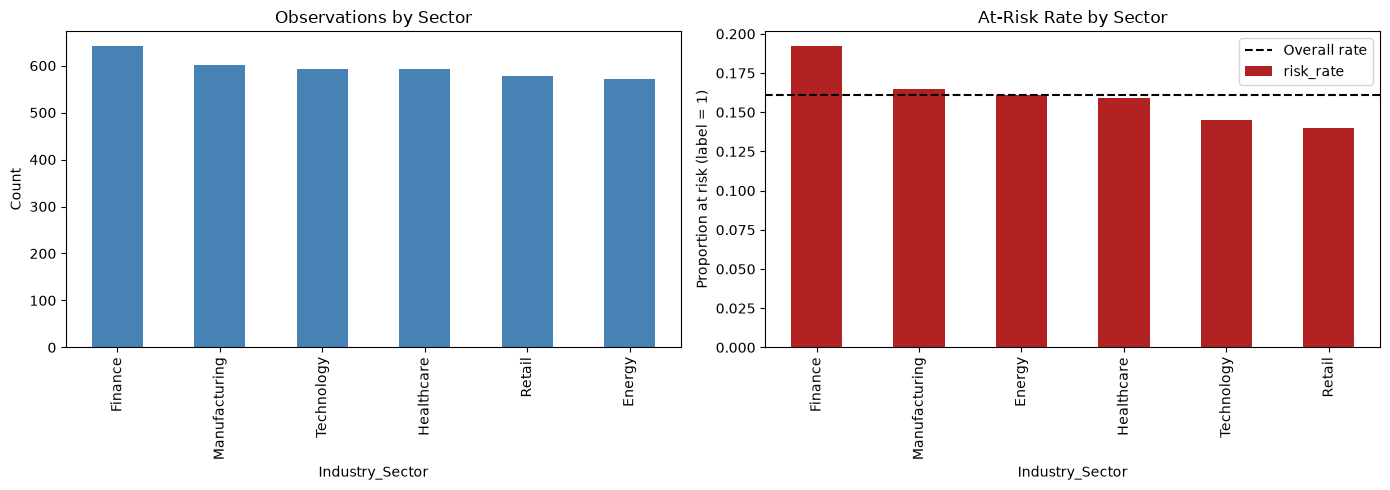

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[SECTOR].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Observations by Sector")
axes[0].set_ylabel("Count")

risk_by_sector["risk_rate"].plot(kind="bar", ax=axes[1], color="firebrick")
axes[1].axhline(df[RISK].mean(), color="black", linestyle="--", label="Overall rate")
axes[1].set_title("At-Risk Rate by Sector")
axes[1].set_ylabel("Proportion at risk (label = 1)")
axes[1].legend()

plt.tight_layout()
plt.show()

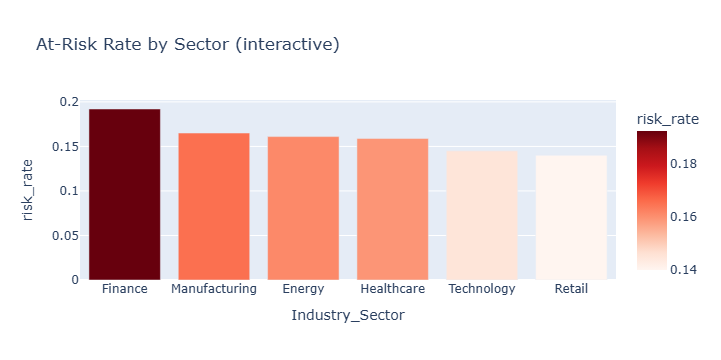

In [5]:
fig = px.bar(
    risk_by_sector.reset_index(),
    x=SECTOR, y="risk_rate", color="risk_rate",
    hover_data=["at_risk", "n"],
    color_continuous_scale="Reds",
    title="At-Risk Rate by Sector (interactive)",
)
fig.show()

## Is the sector difference statistically significant?

In [6]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df[SECTOR], df[RISK])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"Chi-square p-value: {p:.4f}")

Chi-square p-value: 0.1827


## Key Insights

- **Finance has the highest observed risk rate.** 19.2% of Finance observations are labeled at risk (123 of 641), about 3 points above the overall rate of 16.1%.
- **Retail and Technology have the lowest observed rates.** Retail (14.0%) and Technology (14.5%) sit below the overall rate, while Manufacturing (16.5%), Energy (16.1%) and Healthcare (15.9%) are close to average.
- **Ratio differences by sector are small.** Finance has the highest average debt-to-equity (1.177) and the lowest return on assets (0.093), and Technology has the lowest debt-to-equity (1.020) and the highest working capital ratio (8.207). The pattern is not consistent, though: Energy has the lowest working capital ratio (5.109) but an average risk rate.
- **The sector differences are not statistically significant.** A chi-square test of sector vs. risk label gives p = 0.18, so we can't rule out that these gaps are due to chance. Sector alone does not look like a strong predictor of risk, and the next step is to look at the financial ratios and other variables directly.